<a href="https://colab.research.google.com/github/anumit2004/Graph-Attention/blob/main/Multihead_GAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Multi-Head GAT using Pytorch .

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.8 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid

## Flow with Mathametical Explanation :

After the loop finishes, you have $K$ different representations for every single node. The GAT paper handles combining them in two distinct ways, governed by your self.concat flag:Mode A: Concatenation (concat=True)Used for all hidden layers in the network.If you have 8 heads and out_features is 64, the model concatenates them side-by-side.torch.cat(head_outputs, dim=-1) results in a massive new feature vector for each node of size $8 \times 64 = 512$.$$h_i' = \text{ELU}\left(\Big\Vert_{k=1}^{K} \sum_{j \in \mathcal{N}(i)} \alpha_{ij}^k W_k h_j\right)$$(where $\Vert$ denotes concatenation)Mode B: Averaging (concat=False)Used for the final output layer (e.g., right before a softmax for classification).Concatenating at the final layer would change the desired output dimension (e.g., the number of classes). Instead, torch.stack(head_outputs).mean(0) stacks the outputs and calculates the mean across the heads, keeping the final dimension strictly at out_features.$$h_i' = \text{ELU}\left(\frac{1}{K} \sum_{k=1}^{K} \sum_{j \in \mathcal{N}(i)} \alpha_{ij}^k W_k h_j\right)$$Finally, you apply the ELU non-linearity to the combined output. The implementation is structurally sound and mathematically accurate to the original GAT architecture.

In [4]:
def _sparse_softmax(e: torch.tensor , dst : torch.tensor , N : int ):
  """
  e: Attention scores  has dimension (E,) E is the number of nodes .
  dst : Destination nodes of the edges has dimension (E,) E is the number of nodes .
  N: Number of nodes
  """
  e_max = torch.full((N,),float('-inf')) #[N,]
  e_max.scatter_reduce_(0 , dst , e , reduce = 'amax', include_self = True)
  e = torch.exp(e - e_max[dst])

  denom = torch.zeros(N)
  denom.scatter_add_(0,dst,e)

  return e/(denom[dst] + 1e-16)

In [5]:
class GAT_Multihead_Attention(nn.Module):
  def __init__(self, in_features : int , out_features : int , concat : bool = True , n_heads : int = 6 , dropout: float = 0.2 , alpha : float = 0.2 ):
    super().__init__()
    self.in_features = in_features
    self.out_features = out_features
    self.concat = concat
    self.n_heads = n_heads
    self.dropout = dropout
    self.alpha = alpha

    self.W = nn.ModuleList([nn.Linear(in_features , out_features , bias = False) for _ in range(n_heads)])
    self.a_src = nn.ParameterList([nn.Parameter(torch.empty(out_features,1)) for _ in range(n_heads)])
    self.a_dst = nn.ParameterList([nn.Parameter(torch.empty(out_features,1)) for _ in range(n_heads)])

    self.leakyRELU = nn.LeakyReLU(alpha)
    self._init_weights()

  def _init_weights(self):
    for i in range(self.n_heads):
      nn.init.xavier_uniform(self.W[i].weight)
      nn.init.xavier_uniform(self.a_src[i])
      nn.init.xavier_uniform(self.a_dst[i])

  def forward(self, x: torch.tensor , edge_index: torch.tensor ):
    src , dst = edge_index[0] , edge_index[1]  # each [E,]
    N = x.shape[0]
    head_outputs = []

    for k in range(self.n_heads):
      h = self.W[k](x) #[N , out_features]
      h = F.dropout(h, self.dropout, training=self.training)

      e = self.leakyRELU((h @ self.a_src[k])[src] + (h @ self.a_dst[k])[dst]) #[E,]

      alpha = _sparse_softmax(e.squeeze(-1), dst , N) # [E,]
      alpha = F.dropout(alpha, self.dropout, training=self.training)

      out_k = torch.zeros_like(h)
      out_k.scatter_add_(0, dst.unsqueeze(-1).expand(-1, self.out_features)  , alpha.unsqueeze(-1) * h[src])

      head_outputs.append(out_k)

    if self.concat:
      out = torch.cat(head_outputs , dim = -1) # [N , out_features * n_heads]
    else:
      out = torch.stack(head_outputs).mean(dim = 0 ) # [N , out_features]

    return F.elu(out)



In [6]:
def execute_GAT_MHA():
    print("\n" + "="*60)
    print("LEVEL 3: Multi-Head GAT Layer (PyTorch)")
    print("="*60)
    N, F_in = 6, 16
    K = 4   # heads
    x = torch.randn(N, F_in)
    edge_index = torch.tensor([
        [0,1,2,3,4,5,0,2,4],
        [1,2,3,4,5,0,3,5,1]
    ], dtype=torch.long)

    layer = GAT_Multihead_Attention(F_in, out_features=8, n_heads=K, concat=True)
    out = layer(x, edge_index)
    print(f"Input  : {x.shape}")
    print(f"Output (concat): {out.shape}  — expected [{N}, {K*8}]")
    print(f"Sample output (node 0): {out[0].detach().numpy().round(4)}")
    print(f"Sample output (node 1): {out[1].detach().numpy().round(4)}")
    print("\n" + "="*60)

    layer_avg = GAT_Multihead_Attention(F_in, out_features=8, n_heads=K, concat=False)
    out_avg = layer_avg(x, edge_index)
    print(f"Output (avg)   : {out_avg.shape}")
    print(f"Sample output (node 0): {out_avg[0].detach().numpy().round(4)}")
    print(f"Sample output (node 1): {out_avg[1].detach().numpy().round(4)}")
    print("\n" + "="*60)


In [7]:
execute_GAT_MHA()


LEVEL 3: Multi-Head GAT Layer (PyTorch)
Input  : torch.Size([6, 16])
Output (concat): torch.Size([6, 32])  — expected [6, 32]
Sample output (node 0): [ 2.8287  0.      0.      0.      0.4752  1.2004  3.9007  2.6687 -0.7661
 -0.4358  0.147  -0.1075  0.     -0.9478  0.7493 -0.9623  0.3486 -0.9728
 -0.9207  0.     -0.1412  4.1759  0.0111  2.1004  0.      0.      0.
  0.      0.      0.      0.      0.    ]
Sample output (node 1): [-0.2185 -0.8321 -0.4528 -0.25    1.6508 -0.9572 -0.7681  0.      0.1807
 -0.0127  0.2459  0.1809  0.0306  0.     -0.169   0.335   0.     -0.0082
  0.2747  0.      0.1394 -0.2267 -0.3289 -0.2497 -0.6086 -0.2235 -0.4287
 -0.4053 -0.6774 -0.9781  0.3022  1.5789]

Output (avg)   : torch.Size([6, 8])
Sample output (node 0): [-0.4936  0.3375  2.0776  0.6479 -0.7782  0.0105 -0.5175  0.8055]
Sample output (node 1): [-0.6392 -0.2017 -0.4225 -0.428  -0.1626  0.3445 -0.593  -0.461 ]



/tmp/ipykernel_19530/663195976.py:20: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.W[i].weight)
/tmp/ipykernel_19530/663195976.py:21: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.a_src[i])
/tmp/ipykernel_19530/663195976.py:22: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.a_dst[i])


## MultiHeadGAT Classifier

This section defines the `MultiHeadGAT_Classifier` class, which implements a Graph Attention Network (GAT) with multi-head attention for node classification. It consists of two GAT layers:

1.  **First Layer**: Uses multi-head attention with concatenation of head outputs. This layer learns rich, high-dimensional features for each node.
2.  **Second Layer**: Uses multi-head attention with averaging of head outputs. This layer aggregates the features into the final number of classes, followed by a log-softmax activation for classification.

In [12]:
class MultiHeadGAT_Classifier(nn.Module):
    def __init__(self, in_features: int, hidden_features: int, num_classes: int, heads: int = 8, dropout: float = 0.6, alpha: float = 0.2):
        super().__init__()
        self.dropout = dropout

        # Layer 1: Multi-head attention, concatenates heads (Output dimension = hidden_features * heads)
        self.gat1 = GAT_Multihead_Attention(in_features, hidden_features, concat=True, n_heads=heads, dropout=dropout, alpha=alpha)

        # Layer 2: Final prediction layer, averages heads (Output dimension = num_classes)
        # We use a single head here for the final classification, as is standard in the GAT paper.
        self.gat2 = GAT_Multihead_Attention(hidden_features * heads, num_classes, concat=False, n_heads=1, dropout=dropout, alpha=alpha)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)

        # This Log-Softmax prevents the negative loss issue by converting outputs to log-probabilities
        return F.log_softmax(x, dim=1)

# Training over the CORA , CITESEER , PUBMED dataset using Multi-Layer Multi-Head GAT  

In [13]:
def train_and_evaluate_multi_head(dataset_name: str, epochs: int = 200, lr: float = 0.005, weight_decay: float = 5e-4):
    print("\n" + "="*60)
    print(f"Training Multi-Head GAT on {dataset_name} Dataset")
    print("="*60)

    # 1. Load Dataset
    dataset = Planetoid(root=f'/tmp/{dataset_name}', name=dataset_name)
    data = dataset[0]

    # 2. Initialize the Correct Classifier Model
    model = MultiHeadGAT_Classifier(
        in_features=dataset.num_node_features,
        hidden_features=8,      # 8 features per head
        num_classes=dataset.num_classes, # Dynamically matches Cora (7), CiteSeer (6), PubMed (3)
        heads=8,                # 8 attention heads
        dropout=0.6
    )

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.NLLLoss()

    # Metrics storage for plotting
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # 3. Training Loop
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        optimizer.zero_grad()

        out_train = model(data.x, data.edge_index)
        loss = criterion(out_train[data.train_mask], data.y[data.train_mask])

        loss.backward()
        optimizer.step()

        # --- EVALUATION PHASE ---
        model.eval()
        with torch.no_grad():
            # Fresh forward pass without dropout
            out_eval = model(data.x, data.edge_index)
            pred = out_eval.argmax(dim=1)

            # Calculate true training accuracy
            train_correct = pred[data.train_mask] == data.y[data.train_mask]
            train_acc = int(train_correct.sum()) / int(data.train_mask.sum())

            # Calculate validation loss and accuracy
            val_loss = criterion(out_eval[data.val_mask], data.y[data.val_mask])
            val_correct = pred[data.val_mask] == data.y[data.val_mask]
            val_acc = int(val_correct.sum()) / int(data.val_mask.sum())

        # Store metrics
        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss.item())
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1:03d} | Train Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    # 4. Final Testing
    model.eval()
    with torch.no_grad():
        out_test = model(data.x, data.edge_index)
        pred_test = out_test.argmax(dim=1)
        test_correct = pred_test[data.test_mask] == data.y[data.test_mask]
        test_acc = int(test_correct.sum()) / int(data.test_mask.sum())

    print("-" * 60)
    print(f"Final Test Accuracy on {dataset_name}: {test_acc:.4f}")
    print("-" * 60)

    # 5. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Multi-Head GAT Training Dynamics: {dataset_name}', fontsize=16)

    # Loss Plot
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Val Loss', color='orange')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss (NLL)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Accuracy Plot
    ax2.plot(history['train_acc'], label='Train Accuracy', color='green')
    ax2.plot(history['val_acc'], label='Val Accuracy', color='red')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


Training Multi-Head GAT on Cora Dataset


/tmp/ipykernel_19530/663195976.py:20: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.W[i].weight)
/tmp/ipykernel_19530/663195976.py:21: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.a_src[i])
/tmp/ipykernel_19530/663195976.py:22: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.a_dst[i])


Epoch 020 | Train Loss: 1.8729 | Train Acc: 0.8071 | Val Loss: 1.7197 | Val Acc: 0.6600
Epoch 040 | Train Loss: 1.7940 | Train Acc: 0.8214 | Val Loss: 1.5815 | Val Acc: 0.7160
Epoch 060 | Train Loss: 1.7753 | Train Acc: 0.9000 | Val Loss: 1.4751 | Val Acc: 0.7660
Epoch 080 | Train Loss: 1.9386 | Train Acc: 0.9286 | Val Loss: 1.4292 | Val Acc: 0.7900
Epoch 100 | Train Loss: 1.6920 | Train Acc: 0.9643 | Val Loss: 1.3799 | Val Acc: 0.8100
Epoch 120 | Train Loss: 1.6032 | Train Acc: 0.9571 | Val Loss: 1.3369 | Val Acc: 0.8060
Epoch 140 | Train Loss: 1.5251 | Train Acc: 0.9786 | Val Loss: 1.3049 | Val Acc: 0.8060
Epoch 160 | Train Loss: 1.6460 | Train Acc: 0.9857 | Val Loss: 1.2829 | Val Acc: 0.8020
Epoch 180 | Train Loss: 1.6208 | Train Acc: 0.9857 | Val Loss: 1.2651 | Val Acc: 0.7980
Epoch 200 | Train Loss: 1.5608 | Train Acc: 0.9857 | Val Loss: 1.2374 | Val Acc: 0.8040
------------------------------------------------------------
Final Test Accuracy on Cora: 0.7990
-----------------------

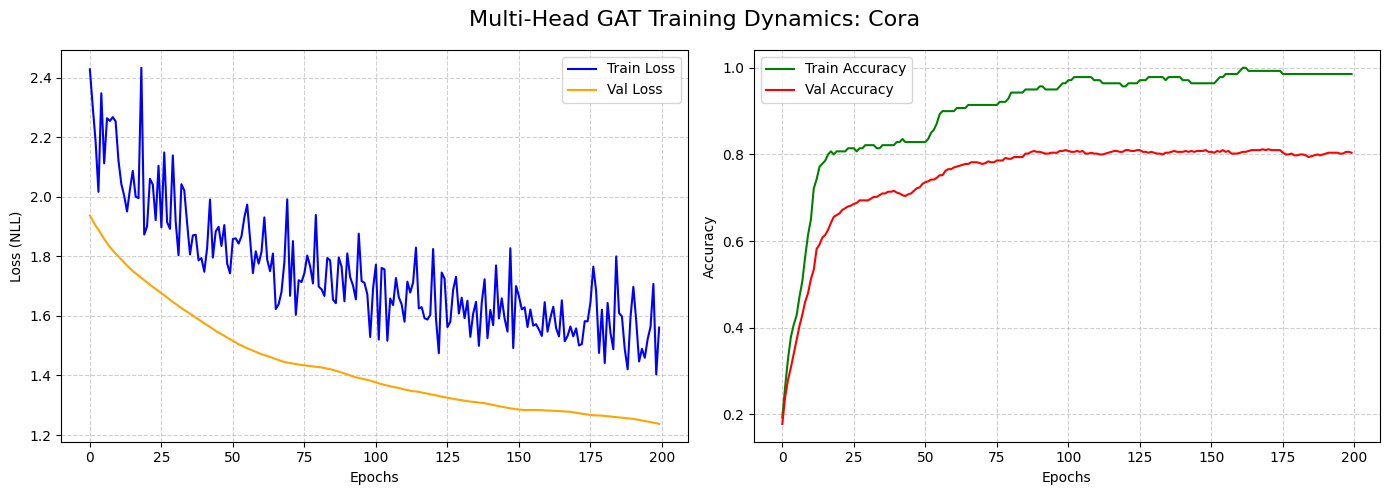


Training Multi-Head GAT on CiteSeer Dataset
Epoch 020 | Train Loss: 2.1906 | Train Acc: 0.7917 | Val Loss: 1.5457 | Val Acc: 0.6040
Epoch 040 | Train Loss: 1.8111 | Train Acc: 0.8750 | Val Loss: 1.5107 | Val Acc: 0.6180
Epoch 060 | Train Loss: 1.8470 | Train Acc: 0.9000 | Val Loss: 1.4897 | Val Acc: 0.6300
Epoch 080 | Train Loss: 1.8495 | Train Acc: 0.9500 | Val Loss: 1.4658 | Val Acc: 0.6440
Epoch 100 | Train Loss: 1.5592 | Train Acc: 0.9667 | Val Loss: 1.4210 | Val Acc: 0.6480
Epoch 120 | Train Loss: 1.7045 | Train Acc: 0.9667 | Val Loss: 1.4155 | Val Acc: 0.6380
Epoch 140 | Train Loss: 1.6866 | Train Acc: 0.9583 | Val Loss: 1.4094 | Val Acc: 0.6540
Epoch 160 | Train Loss: 1.4578 | Train Acc: 0.9500 | Val Loss: 1.3965 | Val Acc: 0.6580
Epoch 180 | Train Loss: 1.5883 | Train Acc: 0.9833 | Val Loss: 1.3941 | Val Acc: 0.6460
Epoch 200 | Train Loss: 1.4967 | Train Acc: 0.9833 | Val Loss: 1.3753 | Val Acc: 0.6680
------------------------------------------------------------
Final Test Acc

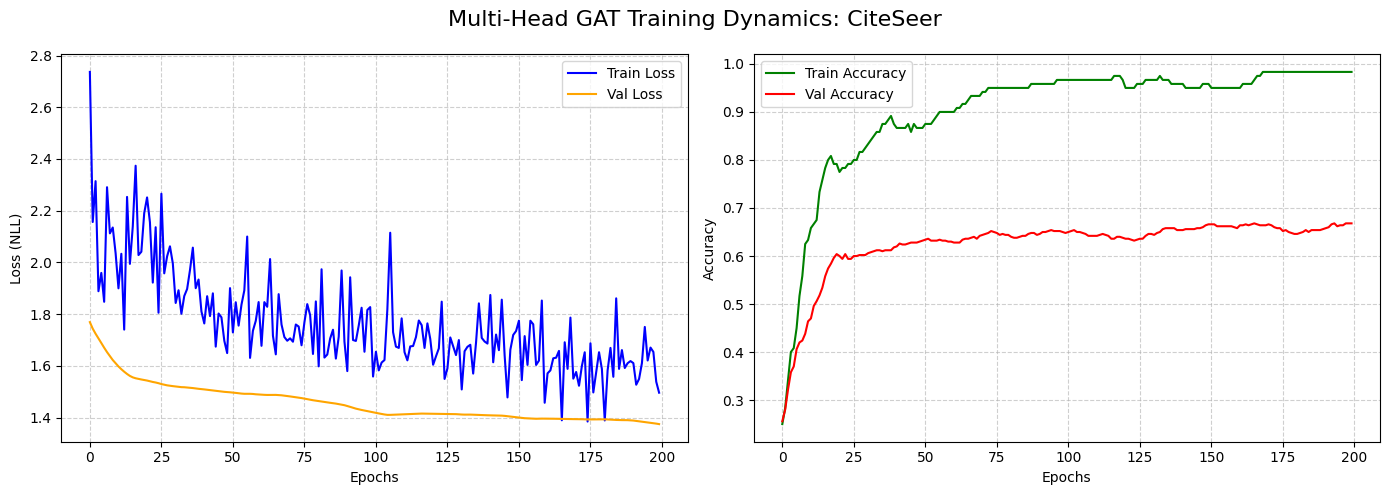


Training Multi-Head GAT on PubMed Dataset
Epoch 020 | Train Loss: 0.9955 | Train Acc: 0.8667 | Val Loss: 1.0014 | Val Acc: 0.7060
Epoch 040 | Train Loss: 0.8101 | Train Acc: 0.9167 | Val Loss: 0.9272 | Val Acc: 0.7220
Epoch 060 | Train Loss: 0.8742 | Train Acc: 0.9167 | Val Loss: 0.8693 | Val Acc: 0.7560
Epoch 080 | Train Loss: 0.9724 | Train Acc: 0.9333 | Val Loss: 0.8310 | Val Acc: 0.7780
Epoch 100 | Train Loss: 0.8058 | Train Acc: 0.9500 | Val Loss: 0.7947 | Val Acc: 0.7860
Epoch 120 | Train Loss: 0.8585 | Train Acc: 0.9500 | Val Loss: 0.7763 | Val Acc: 0.7860
Epoch 140 | Train Loss: 0.7705 | Train Acc: 0.9500 | Val Loss: 0.7654 | Val Acc: 0.7860
Epoch 160 | Train Loss: 0.7954 | Train Acc: 0.9667 | Val Loss: 0.7521 | Val Acc: 0.7800
Epoch 180 | Train Loss: 0.7340 | Train Acc: 0.9667 | Val Loss: 0.7366 | Val Acc: 0.7820
Epoch 200 | Train Loss: 0.7676 | Train Acc: 1.0000 | Val Loss: 0.7233 | Val Acc: 0.7800
------------------------------------------------------------
Final Test Accur

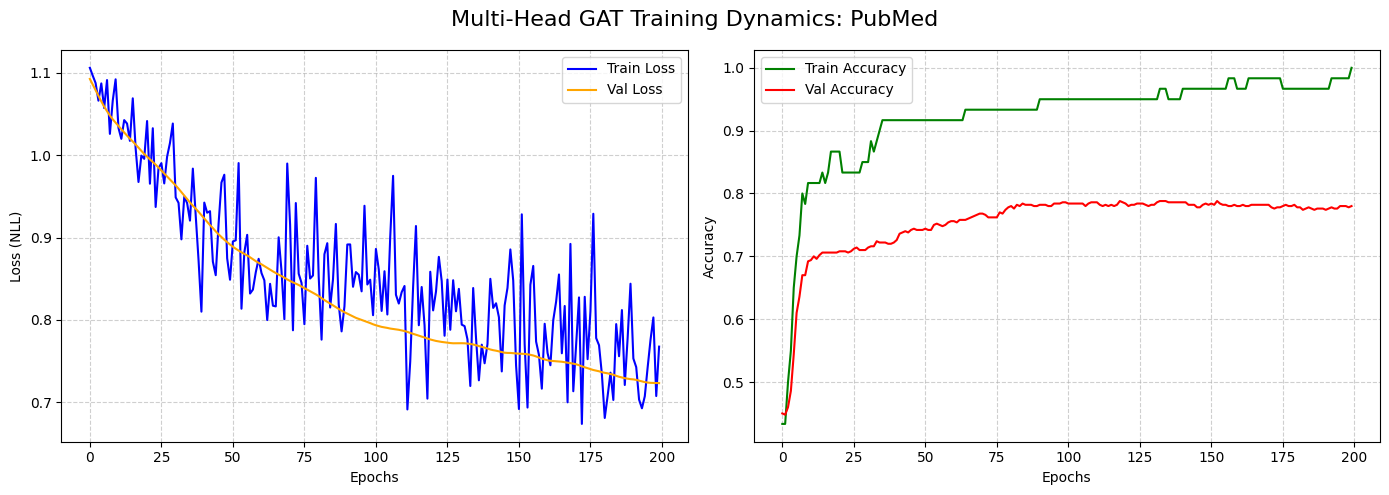

In [14]:
datasets = ['Cora', 'CiteSeer', 'PubMed']

for ds in datasets:
    # Feel free to adjust epochs; Multi-head models sometimes converge faster but might need tuning
    train_and_evaluate_multi_head(ds, epochs=200, lr=0.005)